# MalthusJAX Genome Module — Technical Overview & Guide

This notebook provides an **executable, interactive guide** to the `malthusjax.core.genome` package. 

**Target audience**: Developers implementing, extending, or using genome types and population containers in MalthusJAX.

**What you'll learn**:
- The **Struct-of-Arrays (SoA)** paradigm for efficient JAX vectorization
- How to create, configure, and mutate **genomes** and **populations**
- **JAX integration**: vmap, jit, and immutability patterns
- **Distance metrics** and polymorphic genome comparisons
- Working with **RealGenome** (continuous), **BinaryGenome** (discrete), and **CategoricalGenome** (permutations)
- Population-level operations: slicing, filtering, diversity analysis
- Advanced patterns: offspring factories, batched corrections, type-preserving generics

---

In [1]:
from typing import Any, cast

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns

from malthusjax.core.genome.categorical_genome import (
    CategoricalGenomeConfig,
    CategoricalPopulation,
)

# Import MalthusJAX genome modules
# Note: Adjust imports based on actual installed package structure
from malthusjax.core.genome.real_genome import (
    RealGenome,
    RealGenomeConfig,
    RealPopulation,
)

# Display utilities
print("JAX version:", jax.__version__)

JAX version: 0.10.0


## 2. Understanding the Struct-of-Arrays (SoA) Paradigm

### Key Concept
MalthusJAX follows a **Struct-of-Arrays (SoA)** architecture:

- **`BaseGenome`** represents the logic for a *single* individual
- **`BasePopulation[G]`** holds a "lifted" (batched) version where every leaf in the PyTree has a leading population dimension `N`

### Example Structure

**Per-individual (single genome)**:
- `RealGenome.values` → 1-D array `(length,)`

**Population (batched genomes)**:
- `RealPopulation.genes.values` → 2-D array `(N, length)` — each leaf gains a leading `N` dimension

### Why This Matters
1. **JAX-friendly vectorization**: population-level arrays are the same PyTree structure with an added leading axis
2. **Efficient computation**: algorithms operate at the array level using `jax.vmap` for speed and JIT-compatibility
3. **Type safety**: preserves concrete genome types (e.g., `RealGenome` vs. `CategoricalGenome`) through generics `BasePopulation[G]`

In [2]:
# Demonstrate SoA concept with basic JAX arrays

# Single genome example
genome_values_single = jnp.array([0.1, 0.5, -0.3, 0.7, 0.2])
print("=== Single Genome ===")
print(f"Shape: {genome_values_single.shape}")
print(f"Values: {genome_values_single}")

# Population of 8 genomes (each same shape)
genome_values_population = jnp.array(
    [
        [0.1, 0.5, -0.3, 0.7, 0.2],
        [0.2, 0.3, -0.1, 0.9, 0.0],
        [0.0, 0.4, -0.5, 0.6, 0.3],
        [0.3, 0.2, -0.2, 0.8, 0.1],
        [0.1, 0.6, -0.4, 0.5, 0.4],
        [0.2, 0.1, -0.1, 0.7, 0.2],
        [0.0, 0.7, -0.3, 0.6, 0.0],
        [0.4, 0.3, -0.5, 0.8, 0.3],
    ]
)
print("\n=== Population of 8 Genomes ===")
print(f"Shape: {genome_values_population.shape}")
print(f"Population dimension (N): {genome_values_population.shape[0]}")
print(f"Genome dimension: {genome_values_population.shape[1]}")
print(f"First genome: {genome_values_population[0]}")

# Key insight: vmap operates over axis 0
print("\n=== Key Insight: vmap friendly ===")
print("JAX's vmap processes operations over the leading dimension (axis 0)")
print("This allows batched mutations, distance calculations, etc. in a single JAX operation")

=== Single Genome ===
Shape: (5,)
Values: [ 0.1  0.5 -0.3  0.7  0.2]

=== Population of 8 Genomes ===
Shape: (8, 5)
Population dimension (N): 8
Genome dimension: 5
First genome: [ 0.1  0.5 -0.3  0.7  0.2]

=== Key Insight: vmap friendly ===
JAX's vmap processes operations over the leading dimension (axis 0)
This allows batched mutations, distance calculations, etc. in a single JAX operation


## 3. Creating and Configuring Real Genomes

### RealGenomeConfig Fields

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| `shape` | `Tuple[int, ...]` | `()` | Dimensionality of genome (e.g., `(10,)` for 10-D vector, `(5, 3)` for 5×3 matrix) |
| `bounds` | `Tuple[float, float]` | `(-inf, inf)` | (min, max) bounds applied by `autocorrect` |
| `dtype` | `jnp.dtype` | `jnp.float32` | Numeric dtype for values |

### Key Patterns
- Create configurations for different problem dimensions
- Initialize individual genomes using `random_init`
- Use standard Python operations: `len()`, indexing, slicing, iteration

### Important: Indexing Patterns

MalthusJAX uses **PyTree structure** to provide intuitive, type-preserving indexing:

```python
# ✅ Batched genome indexing → returns individual genome (correct type!)
individual = pop.genes[0]              # RealGenome → individual RealGenome
perm_genome = categorical_pop.genes[0] # CategoricalGenome → individual CategoricalGenome
individual.distance(other, ...)        # Works immediately!

# ✅ Batched genome slicing → returns sub-population (same type)
sub_pop = pop.genes[10:20]  # Batched RealGenome with 10 individuals

# ✅ Batched genome iteration → yields individual genomes  
for genome in pop.genes:    # Yields RealGenome individuals
    fitness = evaluate(genome)

# ✅ Single genome value indexing (subscriptable=True only)
scalar_value = single_genome[0]  # Returns scalar from .values
```

**Design philosophy**: The **frozen dataclass structure** automatically reconstructs the correct genome type (via JAX's `tree_map`), so no explicit type dispatch is needed. Elegantly simple! ✨

In [3]:
# Create a configuration for a 10-dimensional optimization problem
config = RealGenomeConfig(shape=(10,), bounds=(-1.0, 1.0), dtype=jnp.float32)
print("=== RealGenomeConfig ===")
print(f"Shape: {config.shape}")
print(f"Bounds: {config.bounds}")
print(f"Dtype: {config.dtype}")

# Initialize a random genome
key = jax.random.PRNGKey(42)
genome = RealGenome.random_init(key, config)
print("\n=== Random RealGenome ===")
print(f"Genome shape: {genome.shape}")
print(f"Genome length: {len(genome)}")
print(f"Values: {genome.values}")

# Standard Python operations
print("\n=== Python Operations on Genome ===")
print(f"First element: {genome[0]}")
print(f"Slice [1:5]: {genome[1:5]}")
print(f"Size property: {genome.size}")

=== RealGenomeConfig ===
Shape: (10,)
Bounds: (-1.0, 1.0)
Dtype: <class 'jax.numpy.float32'>

=== Random RealGenome ===
Genome shape: (10,)
Genome length: 10
Values: [-0.02258086  0.35959435  0.23254299  0.12203217 -0.09871078  0.17173171
 -0.85038114  0.55026674  0.39791846  0.63726735]

=== Python Operations on Genome ===
First element: -0.022580862045288086
Slice [1:5]: [ 0.35959435  0.23254299  0.12203217 -0.09871078]
Size property: 10


## 4. Population Initialization and Batch Operations

### Key Concepts
- **`init_random`**: Creates a population of randomly initialized genomes
- **Batched structure**: Every leaf in the PyTree gains a leading `N` dimension
- **Efficient vectorization**: Ready for JAX vmap operations

### Example: Create a population of 32 individuals in a 10-D continuous space

In [4]:
# Create configuration
config = RealGenomeConfig(shape=(10,), bounds=(-1.0, 1.0), dtype=jnp.float32)

# Initialize a population of 32 individuals
key = jax.random.PRNGKey(0)
pop = RealPopulation.init_random(key, config, size=32)

print("=== RealPopulation ===")
print(f"Population size: {len(pop)}")
print(f"Genes shape: {pop.genes.values.shape}")
print(f"Fitness shape: {pop.fitness.shape}")
print(f"First genome values: {pop.genes.values[0]}")
print(f"First fitness: {pop.fitness[0]}")

# Population-level properties
print("\n=== Population Structure ===")
print(f"Leading dimension (N): {pop.genes.values.shape[0]}")
print(f"Per-genome dimension: {pop.genes.values.shape[1]}")
print("Every leaf in the PyTree has this leading N dimension")

=== RealPopulation ===
Population size: 32
Genes shape: (32, 10)
Fitness shape: (32,)
First genome values: [ 0.68462825 -0.6352427  -0.5456438  -0.75854874 -0.61637306  0.44403005
  0.5308912  -0.6949191   0.9034126  -0.9413791 ]
First fitness: -inf

=== Population Structure ===
Leading dimension (N): 32
Per-genome dimension: 10
Every leaf in the PyTree has this leading N dimension


## 5. Genome Distance Metrics and Polymorphic Comparisons

### Distance Metrics
MalthusJAX supports polymorphic distance computation across all genome types:

- **`EUCLIDEAN`**: L2 norm (default for `RealGenome`)
- **`MANHATTAN`**: L1 norm
- **`HAMMING`**: Bitwise/category mismatch count (default for `BinaryGenome`, `CategoricalGenome`)

### Polymorphic Design
- All genome types implement: `distance(self, other: BaseGenome, metric: str)`
- Algorithms call `.distance()` without assuming concrete type internals
- Each genome type provides sensible defaults for its domain

### Population-Level Operations
- `distance_matrix(metric="euclidean")` → all pairwise distances (shape: N×N)
- Useful for diversity analysis, neighborhood computations, niching

=== Individual Genome Distances (via elegant indexing) ===
Genome 1 type: RealGenome
Genome 2 type: RealGenome
Euclidean distance: 2.2177
Manhattan distance: 4.6696

=== Population Distance Matrix ===
Distance matrix shape: (8, 8)


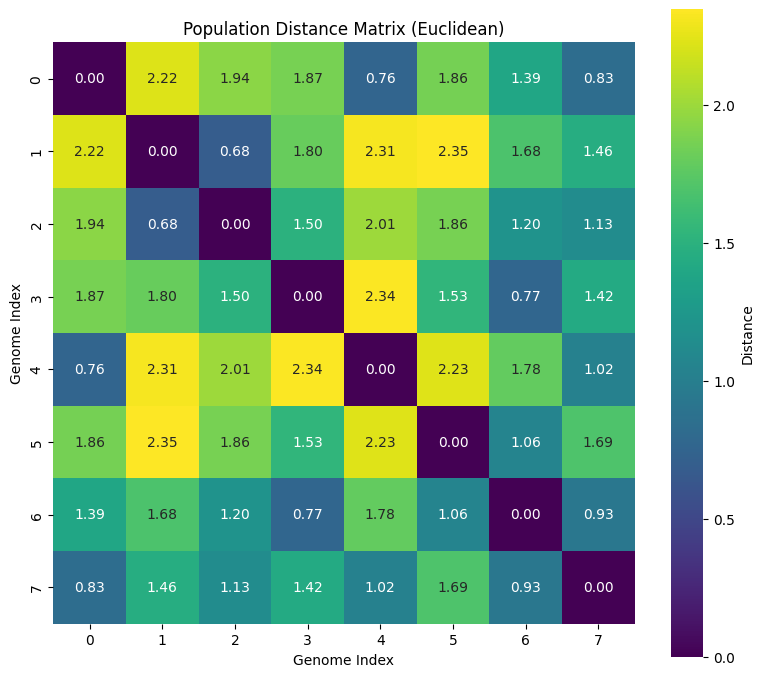


=== Population Diversity ===
Average pairwise distance: 1.5578
Min distance: 0.6806
Max distance: 2.3457


In [5]:
# Create a small population to examine distances
config = RealGenomeConfig(shape=(5,), bounds=(-1.0, 1.0), dtype=jnp.float32)
key = jax.random.PRNGKey(42)
pop = RealPopulation.init_random(key, config, size=8)

print("=== Individual Genome Distances (via elegant indexing) ===")
# Use pop.genes[i] to extract properly reconstructed genome individuals
# PyTree structure automatically handles type reconstruction!
genome1 = pop.genes[0]
genome2 = pop.genes[1]

# Compute distances using different metrics
print(f"Genome 1 type: {type(genome1).__name__}")
print(f"Genome 2 type: {type(genome2).__name__}")
dist_euclidean = genome1.distance(genome2, metric="euclidean")
dist_manhattan = genome1.distance(genome2, metric="manhattan")

print(f"Euclidean distance: {dist_euclidean:.4f}")
print(f"Manhattan distance: {dist_manhattan:.4f}")

# Population-level distance matrix
print("\n=== Population Distance Matrix ===")
dist_matrix = pop.distance_matrix(metric="euclidean")
print(f"Distance matrix shape: {dist_matrix.shape}")

# Plot heatmap of distance matrix
plt.figure(figsize=(8, 7))
sns.heatmap(
    dist_matrix, annot=True, fmt=".2f", cmap="viridis", square=True, cbar_kws={"label": "Distance"}
)
plt.title("Population Distance Matrix (Euclidean)")
plt.xlabel("Genome Index")
plt.ylabel("Genome Index")
plt.tight_layout()
plt.show()

# Compute diversity metrics
print("\n=== Population Diversity ===")
off_diag = jnp.triu_indices(dist_matrix.shape[0], k=1)
pairwise_distances = dist_matrix[off_diag]
avg_diversity = jnp.mean(pairwise_distances)
print(f"Average pairwise distance: {avg_diversity:.4f}")
print(f"Min distance: {jnp.min(pairwise_distances):.4f}")
print(f"Max distance: {jnp.max(pairwise_distances):.4f}")

## 6. JAX Integration: vmap and jit for Genome Mutations

### Key Patterns

**Immutability & Replacement**:
- Genomes are immutable `flax.struct.dataclass` instances
- Mutations use the `.replace(...)` factory method

**Batched Mutations with vmap**:
- Apply per-individual operations across populations using `jax.vmap`
- This is the core pattern for scalable evolutionary algorithms

### Example: Mutate all genomes in a population via Gaussian noise

Each genome will be mutated independently by adding Gaussian noise scaled by a noise parameter.

In [6]:
# Create a population
config = RealGenomeConfig(shape=(5,), bounds=(-1.0, 1.0), dtype=jnp.float32)
key = jax.random.PRNGKey(0)
pop = RealPopulation.init_random(key, config, size=16)

print("=== Original Population ===")
# Elegant indexing via pop.genes[0] returns reconstructed RealGenome
print(f"First genome (type): {type(pop.genes[0]).__name__}")
print(f"First genome values: {pop.genes[0].values}")
print(f"Population min: {jnp.min(pop.genes.values):.4f}")
print(f"Population max: {jnp.max(pop.genes.values):.4f}")

# Generate mutation keys for each individual
key_split = jax.random.split(key, pop.genes.values.shape[0] + 1)
mutation_keys = key_split[1:]


# Define per-individual mutation (add Gaussian noise)
def mutate_single_genome(rng_key, genome):
    """Mutate a single genome by adding Gaussian noise."""
    noise = jax.random.normal(rng_key, genome.values.shape) * 0.1
    new_values = genome.values + noise
    # Clamp to bounds
    new_values = jnp.clip(new_values, *config.bounds)
    return cast(RealGenome, cast(Any, genome).replace(values=new_values))


# Apply mutation via vmap: vectorize over (keys, genomes)
print("\n=== Applying Mutations via vmap ===")
mutate_vmap = jax.vmap(mutate_single_genome, in_axes=(0, 0))
mutated_genes = mutate_vmap(mutation_keys, pop.genes)

# Create new population with mutated genes
mutated_pop = cast(RealPopulation, cast(Any, pop).replace(genes=mutated_genes))

# Access via elegant indexing
print(f"Mutated first genome: {mutated_pop.genes[0].values}")
print(f"Mutated population min: {jnp.min(mutated_pop.genes.values):.4f}")
print(f"Mutated population max: {jnp.max(mutated_pop.genes.values):.4f}")

# Verify mutation
changed = jnp.any(pop.genes.values != mutated_pop.genes.values)
print(f"\nPopulation changed: {changed}")

=== Original Population ===
First genome (type): RealGenome
First genome values: [ 0.68462825 -0.6352427  -0.5456438  -0.75854874 -0.61637306]
Population min: -0.9962
Population max: 0.9805

=== Applying Mutations via vmap ===
Mutated first genome: [ 0.44038266 -0.83881074 -0.5250894  -0.79390377 -0.69257045]
Mutated population min: -1.0000
Mutated population max: 0.9809

Population changed: True


## 7. Working with Categorical Genomes

### Use Cases
- **Permutation problems**: Traveling Salesman Problem (TSP), job scheduling
- **Combinatorial optimization**: SAT, graph coloring, discrete choices
- **Discrete sequences**: Any problem with categorical values in `[0, num_categories)`

### Key Methods
- **`is_permutation()`**: Check if all values are unique (valid permutation)
- **`to_permutation(config)`**: Convert any sequence to a valid permutation via argsort
- **`swap_positions(pos1, pos2)`**: Swap two positions (returns new genome)
- **`count_category(category)`**: Count occurrences of a specific category value
- **`distance(other, metric)`**: Support for Hamming, Euclidean, Manhattan metrics

In [7]:
# Create a population of categorical genomes for TSP (20 cities)
config = CategoricalGenomeConfig(num_categories=20, shape=(20,))
key = jax.random.PRNGKey(42)

# Initialize population
pop = CategoricalPopulation.init_random(key, config, size=16)

print("=== Categorical Genome Population (TSP with 20 cities) ===")
print(f"Population size: {len(pop)}")
print(f"Genome shape: {pop.genes.values.shape}")
print(f"First genome: {pop.genes.values[0]}")

# Elegant indexing: pop.genes[0] automatically reconstructs CategoricalGenome
first_genome = pop.genes[0]
print(f"\nExtracted genome type: {type(first_genome).__name__}")
is_perm = first_genome.is_permutation()
print(f"First genome is a valid permutation: {is_perm}")

# Convert to valid permutation if needed
print("\n=== Converting to Valid Permutation ===")
perm_genome = first_genome.to_permutation(config)
is_perm_after = perm_genome.is_permutation()
print(f"After conversion, is valid permutation: {is_perm_after}")
print(f"Permutation values: {perm_genome.values}")

# Convert entire population to permutations
perm_pop = pop.replace(genes=jax.vmap(lambda g: g.to_permutation(config))(pop.genes))

# Compute diversity
print("\n=== Population Diversity (Hamming Distance) ===")
dist_matrix = perm_pop.distance_matrix(metric="hamming")
off_diag = jnp.triu_indices(dist_matrix.shape[0], k=1)
avg_hamming = jnp.mean(dist_matrix[off_diag])
print(f"Average Hamming distance: {avg_hamming:.2f}")

# Apply swap mutation
print("\n=== Swap Mutation ===")


def swap_mutation(key, genome):
    """Randomly swap two positions."""
    k1, k2 = jax.random.split(key)
    pos1 = jax.random.randint(k1, (), 0, genome.shape[0])
    pos2 = jax.random.randint(k2, (), 0, genome.shape[0])
    return genome.swap_positions(pos1, pos2)


# Apply mutation to population
key_split = jax.random.split(key, pop.genes.values.shape[0] + 1)
mutation_keys = key_split[1:]
mutated_genes = jax.vmap(swap_mutation)(mutation_keys, perm_pop.genes)
mutated_pop = perm_pop.replace(genes=mutated_genes)

print(f"Original first genome: {perm_pop.genes.values[0]}")
print(f"Mutated first genome: {mutated_pop.genes.values[0]}")
same_first = jnp.allclose(
    perm_pop.genes.values[0],
    mutated_pop.genes.values[0],
)
print(f"Genomes differ after mutation: {not same_first}")

=== Categorical Genome Population (TSP with 20 cities) ===
Population size: 16
Genome shape: (16, 20)
First genome: [ 4 11 19  1 10 19  0  9  8 11 16  1  2  7 11  4 19  7  3 19]

Extracted genome type: CategoricalGenome
First genome is a valid permutation: False

=== Converting to Valid Permutation ===
After conversion, is valid permutation: True
Permutation values: [ 6  3 11 12 18  0 15 13 17  8  7  4  1  9 14 10  2  5 16 19]

=== Population Diversity (Hamming Distance) ===
Average Hamming distance: 19.08

=== Swap Mutation ===
Original first genome: [ 6  3 11 12 18  0 15 13 17  8  7  4  1  9 14 10  2  5 16 19]
Mutated first genome: [ 6  3 11 12 18  0 15 13 17  8  7  2  1  9 14 10  4  5 16 19]
Genomes differ after mutation: True


## 8. Population Slicing, Indexing, and Diversity Analysis

### Indexing Operations

**Integer indexing** → returns a single unwrapped genome:
```python
individual = pop[0]  # → RealGenome (not wrapped in population)
```

**Slice/fancy indexing** → returns a sub-population:
```python
sub_pop = pop[10:20]  # → RealPopulation with 10 individuals
mask = fitness > threshold
fitted_pop = pop[mask]  # → filtered population
```

### Diversity Analysis
Use distance matrices to compute population-level statistics:
- Average pairwise distance
- Genetic diversity metrics
- Population spread in phenotype/genotype space

In [8]:
# Create a population with simulated fitness
config = RealGenomeConfig(shape=(5,), bounds=(-1.0, 1.0), dtype=jnp.float32)
key = jax.random.PRNGKey(0)
pop = RealPopulation.init_random(key, config, size=32)

# Simulate fitness evaluation (sphere function: sum of squares)
fitness = jnp.sum(pop.genes.values**2, axis=1)
pop_with_fitness = cast(RealPopulation, cast(Any, pop).replace(fitness=fitness))

print("=== Population with Simulated Fitness ===")
print(f"Population size: {len(pop_with_fitness)}")
print(f"Fitness range: [{jnp.min(fitness):.4f}, {jnp.max(fitness):.4f}]")
print(f"Mean fitness: {jnp.mean(fitness):.4f}")

# Integer indexing via population: get single genome
print("\n=== Population Integer Indexing ===")
individual = pop_with_fitness[0]
print(f"Type of pop[0]: {type(individual).__name__}")
print(f"Individual genome values: {individual.values}")

# Slice indexing: get sub-population
print("\n=== Population Slice Indexing ===")
sub_pop = pop_with_fitness[10:20]
print(f"Sub-population type: {type(sub_pop).__name__}")
print(f"Sub-population size: {len(sub_pop)}")
print(f"Sub-population fitness shape: {sub_pop.fitness.shape}")

# Fancy indexing: filter by fitness
print("\n=== Fancy Indexing (Filter by Fitness) ===")
threshold = jnp.median(fitness)
print(f"Fitness threshold (median): {threshold:.4f}")
good_mask = fitness < threshold
elite_pop = pop_with_fitness[good_mask]
print(f"Elite population size: {len(elite_pop)}")
print(f"Elite fitness range: [{jnp.min(elite_pop.fitness):.4f}, {jnp.max(elite_pop.fitness):.4f}]")

# Population diversity analysis
print("\n=== Diversity Analysis ===")
dist_matrix = pop_with_fitness.distance_matrix(metric="euclidean")
off_diag_indices = jnp.triu_indices(dist_matrix.shape[0], k=1)
pairwise_dists = dist_matrix[off_diag_indices]

print(f"Diversity (mean pairwise distance): {jnp.mean(pairwise_dists):.4f}")
print(f"Diversity (std dev): {jnp.std(pairwise_dists):.4f}")
print(f"Population spread (max distance): {jnp.max(pairwise_dists):.4f}")

# Elegant iteration: batched genomes yield individual genomes
print("\n=== Iteration via Batched Genomes ===")
print("Iterating pop.genes (batched) yields individual RealGenome objects:")
for i, genome in enumerate(pop_with_fitness.genes):
    if i >= 3:  # Just show first 3
        print(f"  ... ({len(pop_with_fitness)} total)")
        break
    print(f"  [{i}] {type(genome).__name__} with size={genome.size}")

=== Population with Simulated Fitness ===
Population size: 32
Fitness range: [0.2669, 2.9022]
Mean fitness: 1.7235

=== Population Integer Indexing ===
Type of pop[0]: RealGenome
Individual genome values: [ 0.68462825 -0.6352427  -0.5456438  -0.75854874 -0.61637306]

=== Population Slice Indexing ===
Sub-population type: RealPopulation
Sub-population size: 10
Sub-population fitness shape: (10,)

=== Fancy Indexing (Filter by Fitness) ===
Fitness threshold (median): 1.7953
Elite population size: 16
Elite fitness range: [0.2669, 1.7602]

=== Diversity Analysis ===
Diversity (mean pairwise distance): 1.7779
Diversity (std dev): 0.5052
Population spread (max distance): 3.0755

=== Iteration via Batched Genomes ===
Iterating pop.genes (batched) yields individual RealGenome objects:
  [0] RealGenome with size=5
  [1] RealGenome with size=5
  [2] RealGenome with size=5
  ... (32 total)


## 9. Advanced: Batched Corrections and Offspring Factory Methods

### Autocorrect: Enforce Domain Constraints
Apply `autocorrect` to all individuals in a population in parallel:
```python
corrected_pop = pop.autocorrect(config)
# Ensures all genomes satisfy domain constraints (e.g., bounds for RealGenome)
```

### spawn_offspring: Flexible Population Creation
`BasePopulation.spawn_offspring(new_genes, fitness=None)` creates a new population from a gene PyTree.

**Without fitness** (default: NaN fitness):
```python
offspring_pop = parent_pop.spawn_offspring(new_genes)
# fitness is NaN—signals pending evaluation
```

**With explicit fitness**:
```python
offspring_pop = parent_pop.spawn_offspring(new_genes, fitness=fitness_values)
# Use when fitness is precomputed or available immediately
```

### When to Use Each Form
- **Without `fitness`**: Use in operator code where fitness will be computed later (engine phase). NaN acts as a safety flag—prevents silent use of invalid values.
- **With `fitness`**: Use when fitness is available now or will be immediately overwritten. Avoids allocating temporary NaN arrays.

In [9]:
# Create a population with genomes pushed slightly out of bounds
config = RealGenomeConfig(shape=(5,), bounds=(-1.0, 1.0), dtype=jnp.float32)
key = jax.random.PRNGKey(0)
pop_original = RealPopulation.init_random(key, config, size=8)

# Manually push some values out of bounds for demonstration
out_of_bounds_values = pop_original.genes.values * 1.5  # Some values now outside [-1, 1]
out_of_bounds_genes = cast(
    RealGenome, cast(Any, pop_original.genes).replace(values=out_of_bounds_values)
)
pop_violating = cast(RealPopulation, cast(Any, pop_original).replace(genes=out_of_bounds_genes))

print("=== Out-of-Bounds Check ===")
print(f"Original min: {jnp.min(pop_original.genes.values):.4f}")
print(f"Original max: {jnp.max(pop_original.genes.values):.4f}")
print(f"Violating min: {jnp.min(pop_violating.genes.values):.4f}")
print(f"Violating max: {jnp.max(pop_violating.genes.values):.4f}")
print(f"Bounds: {config.bounds}")

# Apply autocorrect
print("\n=== After Autocorrect ===")
corrected_pop = pop_violating.autocorrect(config)
print(f"Corrected min: {jnp.min(corrected_pop.genes.values):.4f}")
print(f"Corrected max: {jnp.max(corrected_pop.genes.values):.4f}")
all_within = jnp.all(
    (corrected_pop.genes.values >= config.bounds[0])
    & (corrected_pop.genes.values <= config.bounds[1])
)
print(f"All within bounds: {all_within}")

# Demonstrate spawn_offspring
print("\n=== spawn_offspring Examples ===")

# Create mutated genes
mutated_genes = corrected_pop.genes  # Use our corrected genes

# Without fitness: NaN fitness (pending evaluation)
offspring_1 = corrected_pop.spawn_offspring(mutated_genes)
print("\nOffspring without fitness:")
print(f"  Type: {type(offspring_1).__name__}")
print(f"  Population size: {len(offspring_1)}")
print(f"  Fitness values: {offspring_1.fitness}")
print(f"  All fitness are NaN: {jnp.all(jnp.isnan(offspring_1.fitness))}")

# With explicit fitness: precomputed fitness values
precomputed_fitness = jnp.sum(mutated_genes.values**2, axis=1)
offspring_2 = corrected_pop.spawn_offspring(mutated_genes, fitness=precomputed_fitness)
print("\nOffspring with precomputed fitness:")
print(f"  Type: {type(offspring_2).__name__}")
print(f"  Population size: {len(offspring_2)}")
min_fit = jnp.min(offspring_2.fitness)
max_fit = jnp.max(offspring_2.fitness)
print(f"  Fitness range: [{min_fit:.4f}, {max_fit:.4f}]")
print(f"  Any NaN fitness: {jnp.any(jnp.isnan(offspring_2.fitness))}")

=== Out-of-Bounds Check ===
Original min: -0.9854
Original max: 0.9074
Violating min: -1.4781
Violating max: 1.3612
Bounds: (-1.0, 1.0)

=== After Autocorrect ===
Corrected min: -1.0000
Corrected max: 1.0000
All within bounds: True

=== spawn_offspring Examples ===

Offspring without fitness:
  Type: RealPopulation
  Population size: 8
  Fitness values: [nan nan nan nan nan nan nan nan]
  All fitness are NaN: True

Offspring with precomputed fitness:
  Type: RealPopulation
  Population size: 8
  Fitness range: [2.3618, 4.4326]
  Any NaN fitness: False


## Summary & Key Takeaways

### Core Design Principles

1. **Struct-of-Arrays (SoA) Paradigm**: Single individuals and batched populations share the same PyTree structure with an added leading dimension `N`.

2. **Immutability & Pure Functions**: Genomes are frozen `flax.struct.dataclass` instances; mutations use `.replace(...)`. Keep methods pure for JAX compatibility.

3. **Polymorphic Distance**: All genome types implement `distance(other, metric)`. Metrics (`euclidean`, `manhattan`, `hamming`) are domain-appropriate.

4. **Type-Safe Generics**: `BasePopulation[G]` preserves genome types across APIs, improving IDE support and reducing casting.

5. **JAX Integration**: Use `jax.vmap` for batched operations, `jax.jit` for performance, and the `cast(Type, cast(Any, obj).replace(...))` pattern for type-safe mutations.

6. **✨ Elegant PyTree Indexing**: Indexing batched genomes automatically reconstructs the correct subclass type via JAX's `tree_map`. No explicit type dispatch needed!
   - `pop.genes[0]` → `RealGenome` (correct type!)
   - `categorical_pop.genes[0]` → `CategoricalGenome` (correct type!)  
   - Iteration yields individual genomes from batched structure

### Best Practices

- ✅ Use `pop.genes[i]` to extract individual genomes—type reconstruction is automatic
- ✅ Iterate `pop.genes` to yield individual RealGenome/CategoricalGenome objects
- ✅ Use `jax.vmap` for batched mutations, distances, and evaluations
- ✅ Apply `autocorrect` after operations that might violate bounds
- ✅ Use `spawn_offspring` with NaN fitness for lazy evaluation (engine phase)
- ✅ Compute diversity via `distance_matrix()` for niching algorithms
- ✅ Extend `BaseGenome` and `BasePopulation[G]` for domain-specific behavior

---